# Lesson 0002: a hidden layer learns a V

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tamnd/soroban/blob/main/lessons/0002-hidden-layer/lesson.ipynb)

This notebook is the runnable half of lesson 0002. The full writeup, with every step of the hand arithmetic, is in the [lesson README](https://github.com/tamnd/soroban/tree/main/lessons/0002-hidden-layer). Same contract as lesson 0001: you have computed a training run on paper, and the code below has to agree with your paper, digit for digit, with an `assert` guarding every important number.

The data this time follows $y = |x|$, a V shape, and a V is a problem no single neuron can solve, because a single neuron is a line. The fix is the two ideas that make a network out of neurons: a hidden layer, and the [relu activation function](https://github.com/tamnd/soroban/blob/main/maths/relu.md). The model becomes

$$\hat{y} = v_1 \, \mathrm{relu}(w_1 x + b_1) + v_2 \, \mathrm{relu}(w_2 x + b_2) + c$$

with seven knobs where lesson 0001 had two. Here is the whole notebook in one animation, rendered with manim from this lesson's `visuals.py`:

![the bent line learning the V](https://raw.githubusercontent.com/tamnd/soroban/main/lessons/0002-hidden-layer/assets/fit.gif)

## 0. The wall a line cannot climb

First, the villain. By symmetry the best line for this data is flat at the average height 1.5, and it misses every point by exactly 0.5, for a loss of 0.25 that no line can beat (the [README](https://github.com/tamnd/soroban/tree/main/lessons/0002-hidden-layer) has the argument):

![the best possible line, stuck at loss 0.25](https://raw.githubusercontent.com/tamnd/soroban/main/lessons/0002-hidden-layer/assets/floor.png)

The cell below confirms the champion line's loss. The number 0.25 is the floor the bent model has to break through.

In [1]:
import numpy as np

x = np.array([-2.0, -1.0, 1.0, 2.0])
y = np.array([2.0, 1.0, 1.0, 2.0])  # secretly y = |x|

best_line = np.full(4, 1.5)  # the best any line can do: flat, at the mean of y
line_floor = ((best_line - y) ** 2).mean()
print("the best line's loss:", line_floor)
assert line_floor == 0.25

the best line's loss: 0.25


## 1. The fix: two relus make a V

$\mathrm{relu}(z) = \max(0, z)$ passes positive inputs through and turns negative ones to 0, which makes a relu neuron a line with a switch: on where its line is positive, flat zero elsewhere. Two switched lines are enough for a V, because of an identity you can check by hand: $\mathrm{relu}(x) + \mathrm{relu}(-x) = |x|$, each relu owning one arm and sleeping on the other side.

![relu(x) and relu(-x) summing to the V](https://raw.githubusercontent.com/tamnd/soroban/main/lessons/0002-hidden-layer/assets/arms.png)

The lesson starts the seven knobs at a fixed position chosen for clean arithmetic (real networks start random, and the failure section below shows both why random and why not zero): each hidden neuron leans toward one arm, at the wrong height, so training has real work to do.

In [2]:
def relu(z):
    return np.maximum(0.0, z)

w1, b1 = 1.0, -0.5   # neuron 1: a right arm, wrong height
w2, b2 = -1.0, -0.5  # neuron 2: a left arm, wrong height
v1, v2, c = 1.0, 1.0, 0.0

z1, z2 = w1 * x + b1, w2 * x + b2
h1, h2 = relu(z1), relu(z2)
y_hat = v1 * h1 + v2 * h2 + c
e = y_hat - y
loss = (e**2).mean()

print("h1:   ", h1, "  (neuron 1 awake on the right)")
print("h2:   ", h2, "  (neuron 2 awake on the left)")
print("y_hat:", y_hat)
print("e:    ", e)
print("loss: ", loss)
assert loss == 0.25  # starts exactly at the line's floor

h1:    [0.  0.  0.5 1.5]   (neuron 1 awake on the right)
h2:    [1.5 0.5 0.  0. ]   (neuron 2 awake on the left)
y_hat: [1.5 0.5 0.5 1.5]
e:     [-0.5 -0.5 -0.5 -0.5]
loss:  0.25


## 2. The backward pass grows a second link

The [chain rule](https://github.com/tamnd/soroban/blob/main/maths/chain-rule.md) now runs through relu, whose slope is the friendliest in the course: 1 where the neuron is on, 0 where it is off. That slope acts as a gate on the gradient. For one point, the slope of the loss with respect to $w_1$ multiplies four stages:

$$\frac{\partial L_i}{\partial w_1} = 2 e_i \cdot v_1 \cdot g_{1,i} \cdot x_i$$

where $g_1$ is the gate. A shut gate zeroes the whole product: a data point teaches a neuron nothing while that neuron sleeps on it. The seven gradients below are all halves and quarters, exactly as on paper, so the asserts use exact equality (the [floats page](https://github.com/tamnd/soroban/blob/main/maths/floats.md) explains when that is allowed).

In [3]:
g1, g2 = (z1 > 0).astype(float), (z2 > 0).astype(float)
print("gates g1:", g1, "  g2:", g2)

dc = 2 * e.mean()
dv1 = 2 * (e * h1).mean()
dv2 = 2 * (e * h2).mean()
dw1 = 2 * (e * v1 * g1 * x).mean()
db1 = 2 * (e * v1 * g1).mean()
dw2 = 2 * (e * v2 * g2 * x).mean()
db2 = 2 * (e * v2 * g2).mean()

print(f"dw1 {dw1}  db1 {db1}  dw2 {dw2}  db2 {db2}  dv1 {dv1}  dv2 {dv2}  dc {dc}")
assert (dw1, db1, dw2, db2) == (-0.75, -0.5, 0.75, -0.5)
assert (dv1, dv2, dc) == (-0.5, -0.5, -1.0)  # your paper, confirmed

gates g1: [0. 0. 1. 1.]   g2: [1. 1. 0. 0.]
dw1 -0.75  db1 -0.5  dw2 0.75  db2 -0.5  dv1 -0.5  dv2 -0.5  dc -1.0


## 3. The training loop

The [update rule](https://github.com/tamnd/soroban/blob/main/maths/gradient-descent.md) is untouched from lesson 0001, applied to seven knobs instead of two, with lr = 0.1. The asserts pin the first three losses to the hand run: 0.25, then 0.03631953125, then 0.01158249795541518. Watch the final parameters: training ends with the two hidden neurons as mirror images of each other, having rediscovered the two-arm identity on its own.

In [4]:
w1, b1, w2, b2 = 1.0, -0.5, -1.0, -0.5
v1, v2, c = 1.0, 1.0, 0.0
lr = 0.1
losses = []

for step in range(1, 301):
    z1, z2 = w1 * x + b1, w2 * x + b2
    h1, h2 = relu(z1), relu(z2)
    g1, g2 = (z1 > 0).astype(float), (z2 > 0).astype(float)
    e = v1 * h1 + v2 * h2 + c - y
    loss = (e**2).mean()
    losses.append(loss)

    if step == 1:
        assert loss == 0.25
    if step == 2:
        assert abs(loss - 0.03631953125) < 1e-9
    if step == 3:
        assert abs(loss - 0.01158249795541518) < 1e-9

    if step in (1, 2, 3, 10, 50, 300):
        print(f"step {step:3d}  loss {loss:.9f}")

    dc = 2 * e.mean()
    dv1, dv2 = 2 * (e * h1).mean(), 2 * (e * h2).mean()
    dw1, db1 = 2 * (e * v1 * g1 * x).mean(), 2 * (e * v1 * g1).mean()
    dw2, db2 = 2 * (e * v2 * g2 * x).mean(), 2 * (e * v2 * g2).mean()

    w1, b1 = w1 - lr * dw1, b1 - lr * db1
    w2, b2 = w2 - lr * dw2, b2 - lr * db2
    v1, v2, c = v1 - lr * dv1, v2 - lr * dv2, c - lr * dc

print(f"final     w1 {w1:.6f}  b1 {b1:.6f}  w2 {w2:.6f}  b2 {b2:.6f}"
      f"  v1 {v1:.6f}  v2 {v2:.6f}  c {c:.6f}")
assert abs(w1 + w2) < 1e-9 and abs(b1 - b2) < 1e-9  # mirror images, nobody asked them to be

step   1  loss 0.250000000
step   2  loss 0.036319531
step   3  loss 0.011582498
step  10  loss 0.006811121
step  50  loss 0.000992101
step 300  loss 0.000000013
final     w1 1.036709  b1 -0.335362  w2 -1.036709  b2 -0.335362  v1 0.964803  v2 0.964803  c 0.323205


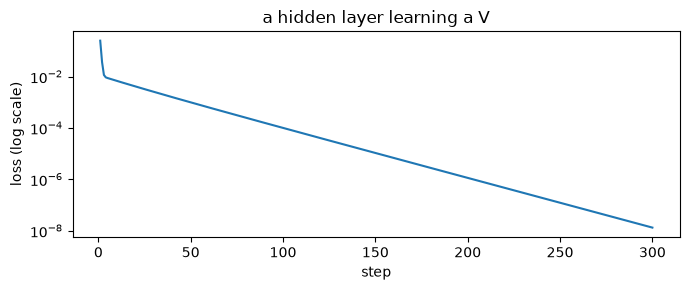

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 3))
plt.semilogy(range(1, 301), losses)
plt.xlabel("step")
plt.ylabel("loss (log scale)")
plt.title("a hidden layer learning a V")
plt.tight_layout()
plt.show()

## 4. Torch does the seven-slope backward pass for free

Deriving seven gradients by hand took the longest section of the README. [Automatic differentiation](https://github.com/tamnd/soroban/blob/main/maths/autodiff.md) gets all seven from the forward formula alone, and the cell asserts they match your paper exactly, not approximately.

In [6]:
try:
    import torch

    xt = torch.tensor([-2.0, -1.0, 1.0, 2.0])
    yt = torch.tensor([2.0, 1.0, 1.0, 2.0])
    p = {name: torch.tensor([val], requires_grad=True)
         for name, val in [("w1", 1.0), ("b1", -0.5), ("w2", -1.0), ("b2", -0.5),
                           ("v1", 1.0), ("v2", 1.0), ("c", 0.0)]}

    ty = (p["v1"] * torch.relu(p["w1"] * xt + p["b1"])
          + p["v2"] * torch.relu(p["w2"] * xt + p["b2"]) + p["c"])
    tloss = ((ty - yt) ** 2).mean()
    tloss.backward()

    grads = {name: t.grad.item() for name, t in p.items()}
    print("torch:", tloss.item(), grads)
    assert tloss.item() == 0.25
    assert grads == {"w1": -0.75, "b1": -0.5, "w2": 0.75, "b2": -0.5,
                     "v1": -0.5, "v2": -0.5, "c": -1.0}
    print("torch agrees with your paper, all seven gradients exact")
except ImportError:
    print("torch not installed, skipping this check (on Colab it just runs)")

torch not installed, skipping this check (on Colab it just runs)


## 5. Break it on purpose

Hidden layers add a genuinely new way to fail. The learning-rate ladder below has lesson 0001's three signatures plus a fourth: at lr = 0.5 the loss does not explode and does not descend, it pins itself to 0.25, the flat line's floor, forever. That is the dying relu problem (the [relu page](https://github.com/tamnd/soroban/blob/main/maths/relu.md) has the formal story): two violent early steps push both hidden neurons to where their gates are shut on all four points, and a shut gate means a zero gradient, so the very updates that could revive them can never arrive. Only $c$ still learns, and it walks to 1.5 and stops.

In [7]:
def first_losses(lr_try, steps=5, init=(1.0, -0.5, -1.0, -0.5, 1.0, 1.0, 0.0)):
    w1, b1, w2, b2, v1, v2, c = init
    out = []
    gates_open = []
    for _ in range(steps):
        z1, z2 = w1 * x + b1, w2 * x + b2
        h1, h2 = relu(z1), relu(z2)
        g1, g2 = (z1 > 0).astype(float), (z2 > 0).astype(float)
        e = v1 * h1 + v2 * h2 + c - y
        out.append((e**2).mean())
        gates_open.append(int(g1.sum() + g2.sum()))
        dc = 2 * e.mean()
        dv1, dv2 = 2 * (e * h1).mean(), 2 * (e * h2).mean()
        dw1, db1 = 2 * (e * v1 * g1 * x).mean(), 2 * (e * v1 * g1).mean()
        dw2, db2 = 2 * (e * v2 * g2 * x).mean(), 2 * (e * v2 * g2).mean()
        w1, b1 = w1 - lr_try * dw1, b1 - lr_try * db1
        w2, b2 = w2 - lr_try * dw2, b2 - lr_try * db2
        v1, v2, c = v1 - lr_try * dv1, v2 - lr_try * dv2, c - lr_try * dc
    return out, gates_open

for lr_try in (0.1, 0.3, 0.5, 0.8):
    losses5, gates5 = first_losses(lr_try)
    row = "  ".join(f"{l:12.4g}" for l in losses5)
    print(f"lr {lr_try}:  {row}   open gates per step: {gates5}")

lr 0.1:          0.25       0.03632       0.01158      0.009346       0.00878   open gates per step: [4, 4, 4, 4, 4]
lr 0.3:          0.25        0.3025        0.5615        0.3869        0.5917   open gates per step: [4, 4, 4, 4, 4]
lr 0.5:          0.25         1.731         5.383          0.25          0.25   open gates per step: [4, 4, 0, 0, 0]
lr 0.8:          0.25         6.735         142.3     6.787e+05     3.359e+17   open gates per step: [4, 4, 4, 4, 4]


Read the gate counts on the lr = 0.5 row: 4 open at the start, then 0 from step 3 on. Every hidden gradient is exactly zero from that point, at any learning rate, forever. The other classic failures are here too: zero init leaves only $c$ trainable (loss floors at 0.25), and cloned or dead hidden neurons leave one usable kink where the data needs two (loss floors at 1/6). The README's failure gallery works through each one.

## 6. The valley nobody asked for

The trained model hits the four training points nearly perfectly. Now ask it about points it never saw. Near the corner of the V, both hidden neurons sleep, so the model answers a constant, its bias $c$, and invents a flat valley the true V does not have. The training data contained nothing near the origin, so no gradient ever punished the valley, and training kept it. Fitting the data is not the same as learning the rule; that gap is called generalization, and later lessons measure it properly with held-out data.

model at x = 0.1: 0.32320490640126587    true |x|: 0.1
model at x = 0.0: 0.32320490640126587    true |x|: 0.0


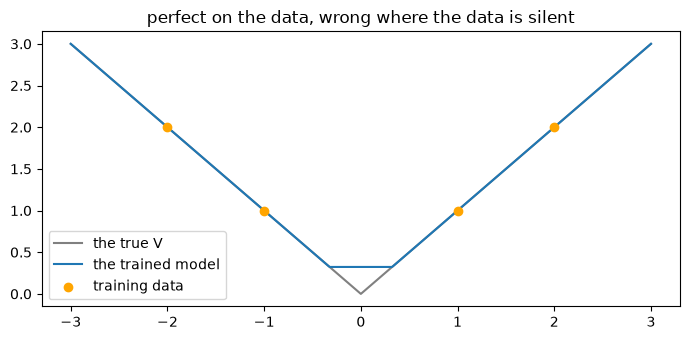

In [8]:
def predict(xs):
    return v1 * relu(w1 * xs + b1) + v2 * relu(w2 * xs + b2) + c

print("model at x = 0.1:", predict(0.1), "   true |x|: 0.1")
print("model at x = 0.0:", predict(0.0), "   true |x|: 0.0")

grid = np.linspace(-3, 3, 601)
model = predict(grid)

plt.figure(figsize=(7, 3.5))
plt.plot(grid, np.abs(grid), color="grey", label="the true V")
plt.plot(grid, model, label="the trained model")
plt.scatter(x, y, color="orange", zorder=3, label="training data")
plt.legend()
plt.title("perfect on the data, wrong where the data is silent")
plt.tight_layout()
plt.show()

## 7. Exercises

1. Predict, then run, lr = 0.3 for 100 steps. The loss rises at step 2. Is it dying, diverging, or fine?
2. Break the clone tie by a hair, `w2 = 0.999`, and rerun. Does training escape the 1/6 floor? The answer is not the obvious one.
3. Zero init and lr = 0.5 both end at loss 0.25 with c = 1.5. Could either be rescued by changing the learning rate?

Answers and discussion are at the end of the [lesson README](https://github.com/tamnd/soroban/tree/main/lessons/0002-hidden-layer), along with the exit test: a fresh dataset (an off-center V) to train by hand, with every number to check yourself against. When your paper and your asserts agree, you are done, and lesson 0003 moves from fitting numbers to choosing categories.